# Criação de Máscara de exclusão Completa

## Imports

In [4]:
import rasterio
import rasterio.features
import geopandas as gpd
import gcsfs
import numpy as np
import os
import tempfile
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv
from rasterio import plot

## Paths

In [5]:
dotenv_path = find_dotenv()
load_dotenv(dotenv_path)
project_root = os.path.dirname(dotenv_path)

KEY_PATH_RELATIVE = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
if KEY_PATH_RELATIVE:
    KEY_PATH_ABSOLUTE = os.path.join(project_root, KEY_PATH_RELATIVE)
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = KEY_PATH_ABSOLUTE
else:
    print("Aviso: GOOGLE_APPLICATION_CREDENTIALS não encontrada no .env")

BUCKET_NAME = os.getenv("GCS_BUCKET_NAME")
PROJECT_ID = os.getenv("GCP_PROJECT_ID")

TEMPLATE_RASTER_PATH = (
    f"gs://{BUCKET_NAME}/raw/topography/declividade_brasil_srtm_1km.tif"
)
MASK_RASTER_DECLIVIDADE_PATH = (
    f"gs://{BUCKET_NAME}/processed/mascara_declividade_maior_5graus.tif"
)
MASK_VETOR_CONSOLIDADO_PATH = (
    f"gs://{BUCKET_NAME}/processed/mascara_exclusao_final.gpkg"
)

STATES_PATH = f"gs://{BUCKET_NAME}/raw/state_lines/BR_UF_2024.shp"
FINAL_MASK_PATH = f"gs://{BUCKET_NAME}/processed/mascara_exclusao_total.tif"

## Carregamento de Dados

### Máscara de declividade

In [ ]:
print("Carregando máscara base (declividade) e perfil do molde...")

fs = gcsfs.GCSFileSystem(project=PROJECT_ID)

with fs.open(MASK_RASTER_DECLIVIDADE_PATH, "rb") as f:
    with rasterio.open(f) as src:
        profile_molde = src.profile
        mascara_final = src.read(1)
        shape_molde = src.shape
        transform_molde = src.transform
        crs_molde = src.crs

print(f"Molde carregado. Dimensões: {shape_molde}, CRS: {crs_molde.to_string()}")

Carregando máscara base (declividade) e perfil do molde...
Molde carregado. Dimensões: (4345, 5026), CRS: EPSG:4326


### Função auxiliar para rasterizar a máscara das áreas de restrição

In [7]:
def rasterizar_vetor(vetor_path, shape_molde, transform_molde, crs_molde):
    """
    Converte um arquivo de vetor (gpkg) em um raster binário (máscara).
    """
    print(f"Rasterizando: {vetor_path.split('/')[-1]}...")
    try:
        gdf = gpd.read_file(vetor_path)

        if gdf.crs != crs_molde:
            print(f"...Reprojetando vetor de {gdf.crs} para {crs_molde}")
            gdf = gdf.to_crs(crs_molde)

        mascara_vetor = rasterio.features.rasterize(
            shapes=gdf.geometry,
            out_shape=shape_molde,
            transform=transform_molde,
            fill=0,
            default_value=1,
            dtype=rasterio.uint8,
        )
        print("...Rasterização concluída.")
        return mascara_vetor

    except Exception as e:
        print(f"ERRO ao rasterizar {vetor_path}: {e}")
        return np.zeros(shape_molde, dtype=rasterio.uint8)

## Processamento das máscaras

In [8]:
mascara_vetor_consolidada = rasterizar_vetor(
    vetor_path=MASK_VETOR_CONSOLIDADO_PATH,
    shape_molde=shape_molde,
    transform_molde=transform_molde,
    crs_molde=crs_molde,
)

mascara_final = np.logical_or(mascara_final, mascara_vetor_consolidada)

print("\nMáscara de declividade e máscara de vetor consolidado foram combinadas.")

Rasterizando: mascara_exclusao_final.gpkg...
...Reprojetando vetor de EPSG:4674 para EPSG:4326
...Rasterização concluída.

Máscara de declividade e máscara de vetor consolidado foram combinadas.


## Viasualização

Gerando visualização da máscara de exclusão total...


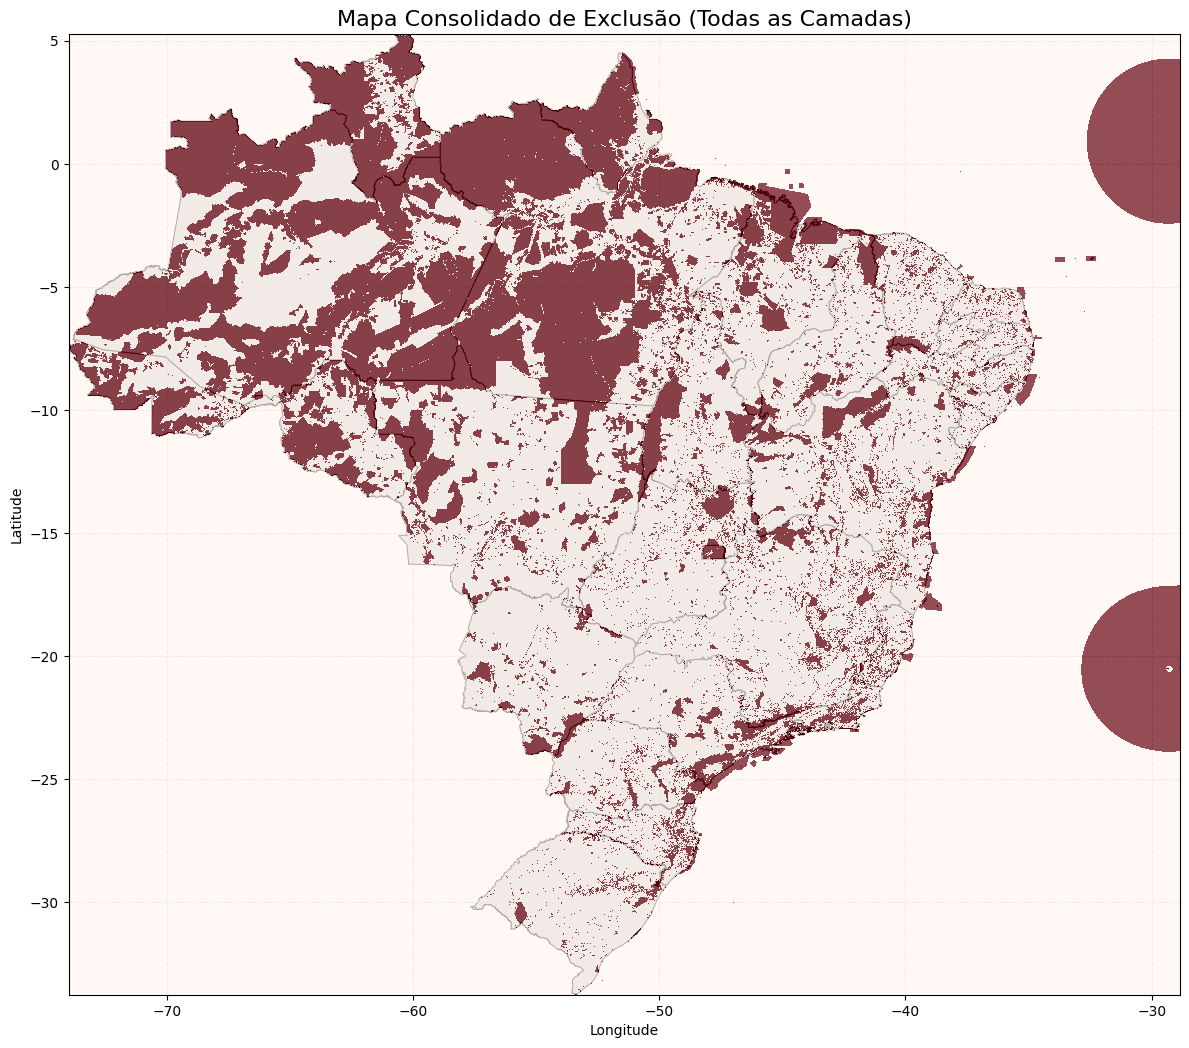

In [9]:
print("Gerando visualização da máscara de exclusão total...")

try:
    br_gdf = gpd.read_file(STATES_PATH)
except Exception as e:
    print(f"AVISO: Não foi possível carregar contorno do Brasil: {e}")
    br_gdf = None

try:
    with fs.open(TEMPLATE_RASTER_PATH, "rb") as f:
        with rasterio.open(f) as src:
            extent = plot.plotting_extent(src)
except Exception as e:
    print(f"ERRO: Não foi possível obter a extensão: {e}")
    extent = None

fig, ax = plt.subplots(figsize=(12, 12))

if br_gdf is not None:
    br_gdf.plot(ax=ax, color="lightgray", edgecolor="black", linewidth=0.7, zorder=1)

if extent is not None:
    plt.imshow(
        mascara_final,
        cmap="Reds",
        extent=extent,
        interpolation="none",
        alpha=0.7,
        zorder=2,
    )
else:
    print("AVISO: 'extent' não definido. Plotando sem alinhamento geográfico.")
    plt.imshow(mascara_final, cmap="Reds", alpha=0.7)

ax.set_title("Mapa Consolidado de Exclusão (Todas as Camadas)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.6)

if br_gdf is not None:
    ax.set_xlim(br_gdf.total_bounds[0], br_gdf.total_bounds[2])
    ax.set_ylim(br_gdf.total_bounds[1], br_gdf.total_bounds[3])

plt.tight_layout()
plt.show()

## Exportação dos Dados

In [10]:
if fs.exists(FINAL_MASK_PATH):
    print("Máscara final já existe no GCS. Pulando etapa de salvamento.")
else:
    print("Salvando máscara final no GCS...")
    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
        local_temp_path = tmp.name

    try:
        profile_molde.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=0)

        with rasterio.open(local_temp_path, "w", **profile_molde) as dst:
            dst.write(mascara_final.astype(rasterio.uint8), 1)

        fs.upload(local_temp_path, FINAL_MASK_PATH)
        print(f"✅ Máscara final salva com sucesso em: gs://{FINAL_MASK_PATH}")

    except Exception as e:
        print(f"❌ Ocorreu um erro ao salvar: {e}")
    finally:
        if os.path.exists(local_temp_path):
            os.remove(local_temp_path)

Salvando máscara final no GCS...
✅ Máscara final salva com sucesso em: gs://gs://tcc-usinas-solares-brasil-dados/processed/mascara_exclusao_total.tif
